In [1]:
# Environment Paths & Directory Setup
import logging
import sys
from pathlib import Path

# Setup Google Drive mount if running in Google Colab
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    has_colab = True
except Exception:
    has_colab = False

# Path Resolution
DEFAULT_COLAB_ROOT = Path("/content/drive/MyDrive/MPLADs")
ALT_COLAB_ROOT = Path("/content/drive/MYDrive/MPLADs")

if has_colab and DEFAULT_COLAB_ROOT.exists():
    PROJECT_ROOT = DEFAULT_COLAB_ROOT
elif has_colab and ALT_COLAB_ROOT.exists():
    PROJECT_ROOT = ALT_COLAB_ROOT
elif (Path.cwd() / "shared_preprocessing_artifacts").exists():
    PROJECT_ROOT = Path.cwd()
elif (Path.cwd().parent / "shared_preprocessing_artifacts").exists():
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

SHARED_ARTIFACT_DIR = PROJECT_ROOT / "shared_preprocessing_artifacts"
FEATURE1_ARTIFACT_DIR = PROJECT_ROOT / "feature1_artifacts"
FEATURE2_ARTIFACT_DIR = PROJECT_ROOT / "feature2_artifacts"
FEATURE3_ARTIFACT_DIR = PROJECT_ROOT / "feature3_artifacts"
FEATURE5_ARTIFACT_DIR = PROJECT_ROOT / "feature5_artifacts"
OUTPUT_DIR = PROJECT_ROOT / "feature7_artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger("mplads_feature7")

logger.info("Project Root: %s", PROJECT_ROOT)
logger.info("Shared Artifacts Dir: %s", SHARED_ARTIFACT_DIR)
logger.info("Feature 7 Output Dir: %s", OUTPUT_DIR)

Mounted at /content/drive


In [2]:
# Cell 2: Data Ingestion & Data Bus Resolution
import pandas as pd
import numpy as np

def read_artifact(dir_path: Path, name: str) -> pd.DataFrame:
    """Reads parquet artifact if available, falling back to CSV."""
    parquet_path = dir_path / f"{name}.parquet"
    csv_path = dir_path / f"{name}.csv"

    if parquet_path.exists():
        try:
            logger.info("Loading parquet: %s", parquet_path)
            return pd.read_parquet(parquet_path)
        except Exception as e:
            logger.warning("Failed loading parquet %s (%s). Falling back to CSV.", parquet_path, e)

    if csv_path.exists():
        logger.info("Loading CSV: %s", csv_path)
        return pd.read_csv(csv_path, low_memory=False)

    raise FileNotFoundError(f"Could not find {name}.parquet or {name}.csv in {dir_path}")

# 1. Load MP Master Dimension Table
dim_mp = read_artifact(SHARED_ARTIFACT_DIR, "dim_mp")
logger.info("Loaded dim_mp shape: %s", dim_mp.shape)

# 2. Resolve Work Data Bus Table (Handoff chain: F5 -> F2 -> F1 -> Shared)
fact_work = None
search_targets = [
    (SHARED_ARTIFACT_DIR, "fact_work_feature5"),
    (FEATURE5_ARTIFACT_DIR, "feature5_fact_work_vendor_risk"),
    (SHARED_ARTIFACT_DIR, "fact_work_feature2"),
    (SHARED_ARTIFACT_DIR, "fact_work_feature1"),
    (SHARED_ARTIFACT_DIR, "fact_work"),
]
for target_dir, target_name in search_targets:
    try:
        fact_work = read_artifact(target_dir, target_name)
        logger.info("Successfully loaded work data bus table from %s/%s. Shape: %s", target_dir.name, target_name, fact_work.shape)
        break
    except Exception:
        continue

if fact_work is None:
    raise FileNotFoundError("Could not locate any valid work fact table on the data bus.")

# 3. Load Expenditure Fact Table
fact_exp = read_artifact(SHARED_ARTIFACT_DIR, "fact_expenditure")
logger.info("Loaded fact_expenditure shape: %s", fact_exp.shape)

# 4. Load Vendor Master Risk Table
vendor_risk = None
try:
    vendor_risk = read_artifact(FEATURE5_ARTIFACT_DIR, "feature5_vendor_risk")
    logger.info("Loaded feature5_vendor_risk shape: %s", vendor_risk.shape)
except Exception as e:
    logger.warning("Could not load feature5_vendor_risk: %s. Using default vendor risk fallback.", e)

In [3]:
# Cell 3: MP-Level Sub-Score Aggregation & Data Preparation
logger.info("--- Computing MP-Level Sub-Scores & Allocation Metrics ---")

# 1. Total Sanctioned Amount per MP
work_sanct = fact_work.groupby("mp_key")["sanction_amount"].sum().rename("total_sanctioned_amount")

# 2. Sub-Score 1: Disbursement Risk Sub-Score (Mean across linked works per MP)
f1_linked = fact_work[fact_work["coverage_flag"] == "linked"].groupby("mp_key")["disbursement_risk_score"].mean().rename("s_f1_linked")
f1_all = fact_work.groupby("mp_key")["disbursement_risk_score"].mean().rename("s_f1_all")

# 3. Sub-Score 2: Cost Risk Sub-Score (Mean across valid cost works per MP)
f2_valid = fact_work[~fact_work["cost_risk_tier"].isin(["Unknown / Invalid"])].groupby("mp_key")["cost_risk_score"].mean().rename("s_f2_valid")
f2_all = fact_work.groupby("mp_key")["cost_risk_score"].mean().rename("s_f2_all")

# 4. Sub-Score 5: Vendor Concentration Sub-Score (Mean vendor_risk_score of top 3 vendors per MP)
if vendor_risk is not None:
    exp_v = fact_exp.merge(vendor_risk[["vendor_id", "vendor_risk_score"]], on="vendor_id", how="left")
else:
    exp_v = fact_exp.copy()
    exp_v["vendor_risk_score"] = 0.0

disb_col = "fund_disbursed_amount" if "fund_disbursed_amount" in exp_v.columns else "amount_disbursed"
exp_v["fund_disbursed_amount"] = pd.to_numeric(exp_v[disb_col], errors="coerce").fillna(0.0)

mp_vendor_spend = exp_v.groupby(["mp_key", "vendor_id"]).agg(
    mp_vendor_spend=("fund_disbursed_amount", "sum"),
    vendor_risk_score=("vendor_risk_score", "first")
).reset_index().sort_values(by=["mp_key", "mp_vendor_spend"], ascending=[True, False])

top3_mp_vendors = mp_vendor_spend.groupby("mp_key").head(3)
f5_top3 = top3_mp_vendors.groupby("mp_key")["vendor_risk_score"].mean().rename("s_f5_top3")

# 5. Build Base MP DataFrame
mp_df = dim_mp[["mp_key", "mp_name_clean", "house", "state", "state_key", "constituency", "allocated_amount"]].copy()
mp_df = mp_df.merge(work_sanct, on="mp_key", how="left")
mp_df["total_sanctioned_amount"] = mp_df["total_sanctioned_amount"].fillna(0.0)

mp_df["allocated_amount"] = pd.to_numeric(mp_df["allocated_amount"], errors="coerce").fillna(0.0)
mp_df["allocation_utilization_pct"] = np.where(
    mp_df["allocated_amount"] > 0,
    (mp_df["total_sanctioned_amount"] / mp_df["allocated_amount"]) * 100.0,
    0.0
)

# Merge Sub-Scores
mp_df = mp_df.merge(f1_linked, on="mp_key", how="left")
mp_df = mp_df.merge(f1_all, on="mp_key", how="left")
mp_df = mp_df.merge(f2_valid, on="mp_key", how="left")
mp_df = mp_df.merge(f2_all, on="mp_key", how="left")
mp_df = mp_df.merge(f5_top3, on="mp_key", how="left")

# Hierarchical Imputation: Linked/Valid -> All Works -> State Median -> Population Median
mp_df["s_f1"] = mp_df["s_f1_linked"].fillna(mp_df["s_f1_all"])
mp_df["s_f2"] = mp_df["s_f2_valid"].fillna(mp_df["s_f2_all"])
mp_df["s_f5"] = mp_df["s_f5_top3"]

s1_med = mp_df["s_f1"].dropna().median() if not mp_df["s_f1"].dropna().empty else 0.0
s2_med = mp_df["s_f2"].dropna().median() if not mp_df["s_f2"].dropna().empty else 0.0
s5_med = mp_df["s_f5"].dropna().median() if not mp_df["s_f5"].dropna().empty else 0.0

mp_df["s_f1"] = mp_df.groupby("state_key")["s_f1"].transform(lambda x: x.fillna(x.median() if x.notna().any() else s1_med)).fillna(s1_med)
mp_df["s_f2"] = mp_df.groupby("state_key")["s_f2"].transform(lambda x: x.fillna(x.median() if x.notna().any() else s2_med)).fillna(s2_med)
mp_df["s_f5"] = mp_df.groupby("state_key")["s_f5"].transform(lambda x: x.fillna(x.median() if x.notna().any() else s5_med)).fillna(s5_med)

logger.info("MP Base Scorecard prepared for %d MPs.", len(mp_df))

In [4]:
# Cell 4: Winsorization, Z-Score Standardization & Pairwise Correlation Diagnostic
logger.info("--- Performing Winsorization, Z-Score Standardization & Correlation Checks ---")

# 1. Outlier Winsorization at 1st and 99th Percentiles
for col in ["s_f1", "s_f2", "s_f5"]:
    p1, p99 = np.percentile(mp_df[col], [1, 99])
    mp_df[f"{col}_winsor"] = np.clip(mp_df[col], p1, p99)
    mu, std = mp_df[f"{col}_winsor"].mean(), mp_df[f"{col}_winsor"].std()
    mp_df[f"z_{col}"] = (mp_df[f"{col}_winsor"] - mu) / (std if std > 0 else 1.0)

# 2. Pairwise Pearson Correlation Matrix R
corr_matrix = mp_df[["z_s_f1", "z_s_f2", "z_s_f5"]].corr()
print("--- Pairwise Pearson Correlation Matrix (R) ---")
print(corr_matrix)

--- Pairwise Pearson Correlation Matrix (R) ---
          z_s_f1    z_s_f2    z_s_f5
z_s_f1  1.000000  0.203295  0.243918
z_s_f2  0.203295  1.000000  0.258629
z_s_f5  0.243918  0.258629  1.000000


In [5]:
# Cell 5: Diagnostic Weight Selection & Baseline Composite Risk Score Assembly
logger.info("--- Assembling Baseline Composite Risk Score & Empirical Percentile Tiering ---")

# Collinearity Check Threshold (r > 0.70)
max_r = max(
    abs(corr_matrix.loc["z_s_f1", "z_s_f2"]),
    abs(corr_matrix.loc["z_s_f1", "z_s_f5"]),
    abs(corr_matrix.loc["z_s_f2", "z_s_f5"])
)

if max_r > 0.70:
    strategy_used = "Strategy C (Dimension-Averaged)"
    logger.info("Collinearity detected (max r = %.3f > 0.70). Applying Strategy C.", max_r)
    w_f1, w_f2, w_f5 = 0.3333333, 0.3333333, 0.3333333
else:
    strategy_used = "Strategy A (Equal Weighting)"
    logger.info("No severe collinearity detected (max r = %.3f <= 0.70). Applying Strategy A (Equal Weighting).", max_r)
    w_f1, w_f2, w_f5 = 0.3333333, 0.3333333, 0.3333333

# Compute Raw Composite Score
mp_df["raw_composite_score"] = w_f1 * mp_df["z_s_f1"] + w_f2 * mp_df["z_s_f2"] + w_f5 * mp_df["z_s_f5"]

# Min-Max Normalization to [0.0, 1.0]
c_min, c_max = mp_df["raw_composite_score"].min(), mp_df["raw_composite_score"].max()
mp_df["composite_risk_score"] = (mp_df["raw_composite_score"] - c_min) / (c_max - c_min) if c_max > c_min else 0.0

# Empirical Risk Tier Cutoffs (Pure Percentiles)
p50, p75, p90 = np.percentile(mp_df["composite_risk_score"], [50, 75, 90])
logger.info("Empirical Percentile Cutoffs -> P50: %.4f, P75: %.4f, P90: %.4f", p50, p75, p90)

def assign_tier(score: float) -> str:
    if score >= p90:
        return "Critical"
    elif score >= p75:
        return "High"
    elif score >= p50:
        return "Medium"
    else:
        return "Low"

mp_df["composite_risk_tier"] = mp_df["composite_risk_score"].apply(assign_tier)

print("--- Baseline Percentile Risk Tier Distribution ---")
print(mp_df["composite_risk_tier"].value_counts())

--- Baseline Percentile Risk Tier Distribution ---
composite_risk_tier
Low         382
Medium      198
High        116
Critical     78
Name: count, dtype: int64


In [6]:
# Cell 6: ML Stretch Layer 1 — Data-Driven Risk Tier Clustering (K-Means & GMM)
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import joblib

logger.info("--- Executing ML Stretch Layer 1: Data-Driven Risk Tier Clustering (K-Means & GMM) ---")

# Feature matrix for clustering: standardized sub-scores
X_subscores = mp_df[["z_s_f1", "z_s_f2", "z_s_f5"]].values

# Fit K-Means with K=4 (corresponding to 4 risk tiers)
n_clusters = min(4, len(mp_df))
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
raw_clusters = kmeans.fit_predict(X_subscores)

# Sort clusters by mean composite_risk_score of members to map to canonical risk tiers
mp_df["temp_cluster"] = raw_clusters
cluster_order = mp_df.groupby("temp_cluster")["composite_risk_score"].mean().sort_values().index.tolist()

tier_names = ["Low", "Medium", "High", "Critical"]
tier_map = {cluster_order[i]: tier_names[min(i, len(tier_names) - 1)] for i in range(len(cluster_order))}
mp_df["mp_kmeans_tier"] = mp_df["temp_cluster"].map(tier_map)
mp_df.drop(columns=["temp_cluster"], inplace=True)

# Fit Gaussian Mixture Model (GMM) as probabilistic clustering baseline
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm.fit(X_subscores)
mp_df["gmm_max_prob"] = gmm.predict_proba(X_subscores).max(axis=1)

# Save K-Means Model Artifact
kmeans_model_path = OUTPUT_DIR / "feature7_kmeans_model.joblib"
joblib.dump({
    "kmeans_model": kmeans,
    "gmm_model": gmm,
    "cluster_tier_map": tier_map,
    "feature_cols": ["z_s_f1", "z_s_f2", "z_s_f5"]
}, kmeans_model_path)
logger.info("Exported K-Means/GMM clustering pipeline to %s", kmeans_model_path.name)

print("--- Data-Driven K-Means Risk Tier Distribution ---")
print(mp_df["mp_kmeans_tier"].value_counts())

--- Data-Driven K-Means Risk Tier Distribution ---
mp_kmeans_tier
Low         544
Medium       90
High         89
Critical     51
Name: count, dtype: int64


In [7]:
# Cell 7: ML Stretch Layer 2 — Multivariate Isolation Forest MP Anomaly Detection & Score Blending
from sklearn.ensemble import IsolationForest

logger.info("--- Executing ML Stretch Layer 2: Multivariate Isolation Forest Anomaly Detection ---")

# Train Isolation Forest on 3D standardized sub-scores (z_s_f1, z_s_f2, z_s_f5)
iforest_mp = IsolationForest(
    n_estimators=100,
    contamination=0.03,
    random_state=42,
    n_jobs=-1
)
iforest_mp.fit(X_subscores)

# Invert score_samples so higher = more anomalous
raw_if_scores_mp = -iforest_mp.score_samples(X_subscores)
if_min, if_max = raw_if_scores_mp.min(), raw_if_scores_mp.max()
mp_df["mp_iforest_score"] = (raw_if_scores_mp - if_min) / (if_max - if_min) if if_max > if_min else 0.0

# Blend Baseline Composite Score (75%) + Isolation Forest Anomaly Score (25%)
mp_df["ml_augmented_composite_risk_score"] = np.clip(
    0.75 * mp_df["composite_risk_score"] + 0.25 * mp_df["mp_iforest_score"],
    0.0, 1.0
)

# Derive ML-Augmented Risk Tiering using Percentile Cutoffs
p50_ml, p75_ml, p90_ml = np.percentile(mp_df["ml_augmented_composite_risk_score"], [50, 75, 90])

def assign_ml_tier(score: float) -> str:
    if score >= p90_ml:
        return "Critical"
    elif score >= p75_ml:
        return "High"
    elif score >= p50_ml:
        return "Medium"
    else:
        return "Low"

mp_df["ml_augmented_risk_tier"] = mp_df["ml_augmented_composite_risk_score"].apply(assign_ml_tier)

# Export Isolation Forest Model Artifact
iforest_model_path = OUTPUT_DIR / "feature7_iforest_model.joblib"
joblib.dump({
    "iforest_model": iforest_mp,
    "score_min": float(if_min),
    "score_max": float(if_max),
    "feature_cols": ["z_s_f1", "z_s_f2", "z_s_f5"]
}, iforest_model_path)
logger.info("Exported Isolation Forest model pipeline to %s", iforest_model_path.name)

print("--- ML-Augmented Risk Tier Distribution ---")
print(mp_df["ml_augmented_risk_tier"].value_counts())

--- ML-Augmented Risk Tier Distribution ---
ml_augmented_risk_tier
Low         387
Medium      193
High        116
Critical     78
Name: count, dtype: int64


In [8]:
# Cell 8: Natural Language Audit Explanation Generator
def generate_mp_explanation(row: pd.Series) -> str:
    """Generates comprehensive natural language explanations incorporating baseline + ML anomaly signals."""
    tier = row["ml_augmented_risk_tier"]
    score = row["ml_augmented_composite_risk_score"]
    mp_name = row["mp_name_clean"] if pd.notna(row["mp_name_clean"]) else row["mp_key"]
    state = row["state"] if pd.notna(row["state"]) else "Unknown State"
    z_f1 = row["z_s_f1"]
    z_f2 = row["z_s_f2"]
    z_f5 = row["z_s_f5"]
    if_score = row["mp_iforest_score"]
    kmeans_tier = row["mp_kmeans_tier"]

    drivers = []
    if z_f1 >= 1.0:
        drivers.append(f"elevated fund disbursement shortfall (Z={z_f1:.2f})")
    if z_f2 >= 1.0:
        drivers.append(f"high sanction cost overruns relative to state peers (Z={z_f2:.2f})")
    if z_f5 >= 1.0:
        drivers.append(f"high spend concentration among top contractors (Z={z_f5:.2f})")
    if if_score >= 0.70:
        drivers.append(f"unusual multivariate sub-score combination detected by Isolation Forest (score: {if_score:.2f})")

    driver_str = "; ".join(drivers) if drivers else f"balanced sub-scores (Z_disb={z_f1:.2f}, Z_cost={z_f2:.2f}, Z_vend={z_f5:.2f})"

    if tier == "Critical":
        return f"CRITICAL COMPOSITE MP RISK (Score: {score:.2f}, Top 10%): MP '{mp_name}' ({state}) exhibits critical anomaly signals driven by {driver_str}. K-Means cluster tag: '{kmeans_tier}'."
    elif tier == "High":
        return f"HIGH COMPOSITE MP RISK (Score: {score:.2f}, Top 25%): MP '{mp_name}' ({state}) shows elevated risk driven by {driver_str}. K-Means cluster tag: '{kmeans_tier}'."
    elif tier == "Medium":
        return f"MODERATE COMPOSITE MP RISK (Score: {score:.2f}): MP '{mp_name}' ({state}) exhibits moderate risk indicators ({driver_str})."
    else:
        return f"LOW COMPOSITE MP RISK (Score: {score:.2f}): MP '{mp_name}' ({state}) shows standard baseline risk across all sub-score dimensions."

mp_df["composite_risk_explanation"] = mp_df.apply(generate_mp_explanation, axis=1)

print("--- Sample Critical MP Audit Explanations (Baseline + ML Signals) ---")
critical_samples = mp_df[mp_df["ml_augmented_risk_tier"] == "Critical"]["composite_risk_explanation"].head(5)
for i, exp in enumerate(critical_samples, 1):
    print(f"{i}. {exp}")

--- Sample Critical MP Audit Explanations (Baseline + ML Signals) ---
1. CRITICAL COMPOSITE MP RISK (Score: 0.55, Top 10%): MP 'AJENDRA SINGH LODHI' (Uttar Pradesh) exhibits critical anomaly signals driven by elevated fund disbursement shortfall (Z=4.46); unusual multivariate sub-score combination detected by Isolation Forest (score: 0.75). K-Means cluster tag: 'Critical'.
2. CRITICAL COMPOSITE MP RISK (Score: 0.46, Top 10%): MP 'ANANTA NAYAK' (Odisha) exhibits critical anomaly signals driven by elevated fund disbursement shortfall (Z=3.71). K-Means cluster tag: 'Critical'.
3. CRITICAL COMPOSITE MP RISK (Score: 0.69, Top 10%): MP 'ASHOK KUMAR RAWAT' (Uttar Pradesh) exhibits critical anomaly signals driven by high sanction cost overruns relative to state peers (Z=3.91); high spend concentration among top contractors (Z=2.02); unusual multivariate sub-score combination detected by Isolation Forest (score: 0.81). K-Means cluster tag: 'Medium'.
4. CRITICAL COMPOSITE MP RISK (Score: 0.49, T

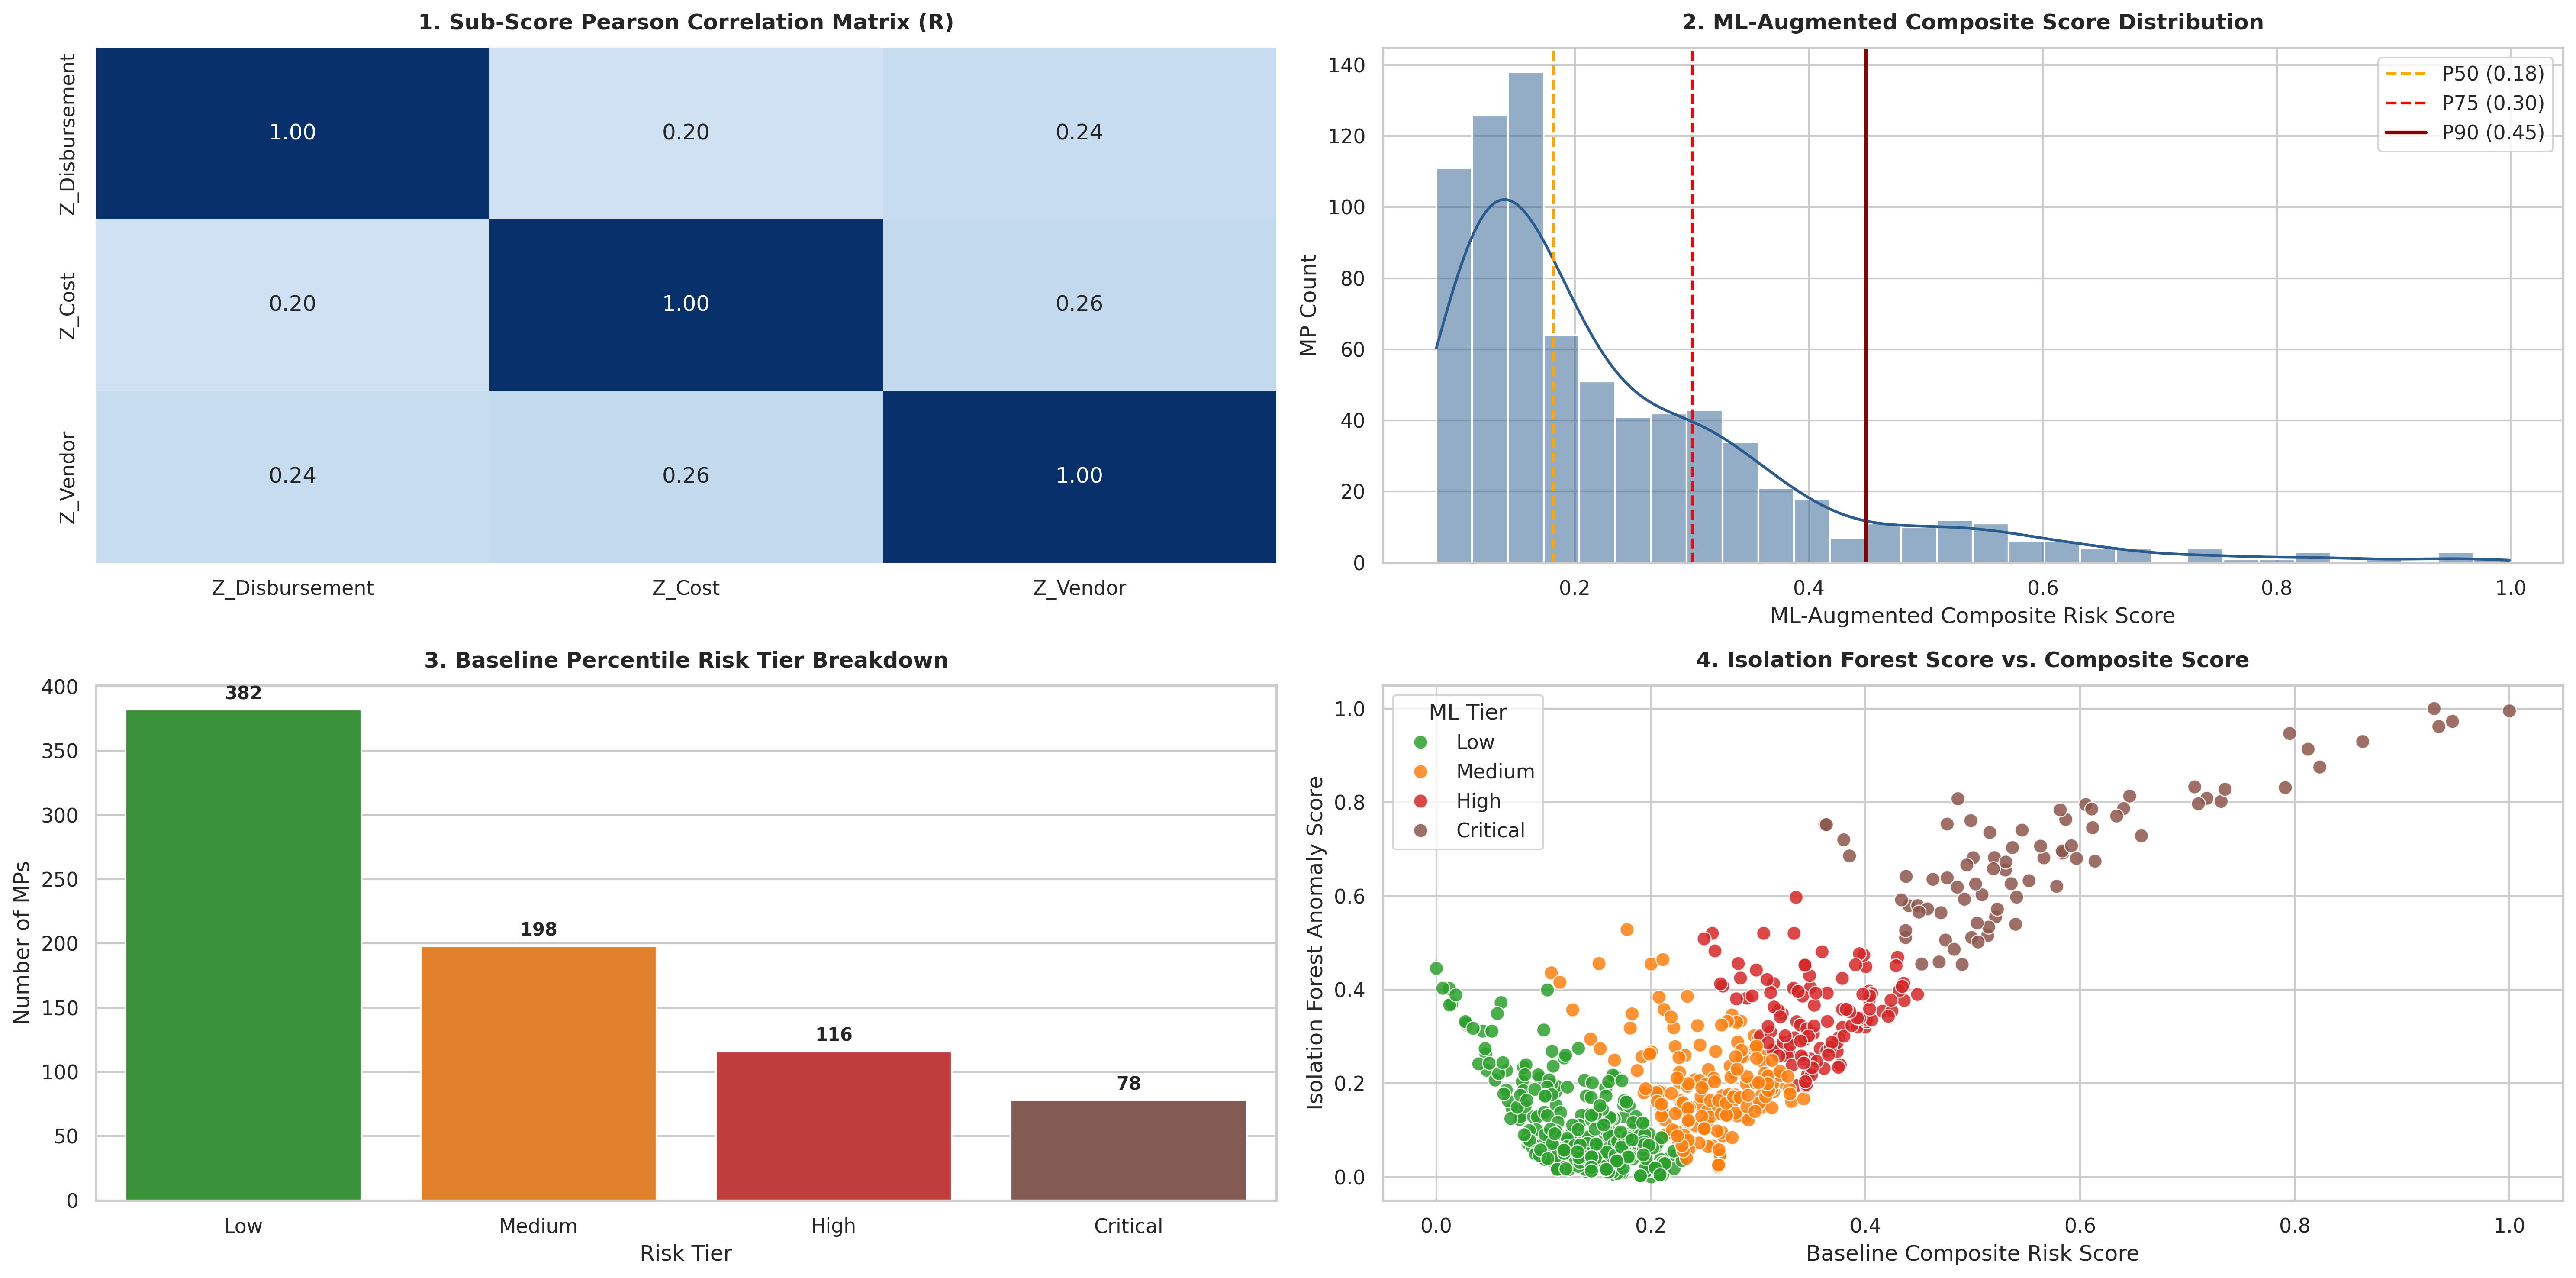

In [9]:
# Cell 9: Diagnostic Visualizations & 4-Panel Summary Figure
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 10), dpi=300)
sns.set_theme(style="whitegrid")

# Panel 1: Sub-Score Pearson Correlation Heatmap
plt.subplot(2, 2, 1)
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f", vmin=0, vmax=1.0, cbar=False,
            xticklabels=["Z_Disbursement", "Z_Cost", "Z_Vendor"],
            yticklabels=["Z_Disbursement", "Z_Cost", "Z_Vendor"])
plt.title("1. Sub-Score Pearson Correlation Matrix (R)", fontsize=12, fontweight="bold", pad=10)

# Panel 2: ML-Augmented Composite Risk Score Distribution
plt.subplot(2, 2, 2)
sns.histplot(mp_df["ml_augmented_composite_risk_score"], kde=True, color="#2b5c8f", bins=30)
plt.axvline(p50_ml, color="orange", linestyle="--", linewidth=1.5, label=f"P50 ({p50_ml:.2f})")
plt.axvline(p75_ml, color="red", linestyle="--", linewidth=1.5, label=f"P75 ({p75_ml:.2f})")
plt.axvline(p90_ml, color="darkred", linestyle="-", linewidth=2.0, label=f"P90 ({p90_ml:.2f})")
plt.title("2. ML-Augmented Composite Score Distribution", fontsize=12, fontweight="bold", pad=10)
plt.xlabel("ML-Augmented Composite Risk Score")
plt.ylabel("MP Count")
plt.legend(loc="upper right")

# Panel 3: Baseline Percentile Risk Tier Breakdown
plt.subplot(2, 2, 3)
tier_order = ["Low", "Medium", "High", "Critical"]
palette = {"Low": "#2ca02c", "Medium": "#ff7f0e", "High": "#d62728", "Critical": "#8c564b"}
sns.countplot(data=mp_df, x="composite_risk_tier", order=tier_order, palette=palette, hue="composite_risk_tier", legend=False)
plt.title("3. Baseline Percentile Risk Tier Breakdown", fontsize=12, fontweight="bold", pad=10)
plt.xlabel("Risk Tier")
plt.ylabel("Number of MPs")
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2., height + 5),
                           ha="center", va="bottom", fontsize=10, fontweight="bold")

# Panel 4: Isolation Forest Anomaly Score vs Composite Risk
plt.subplot(2, 2, 4)
sns.scatterplot(
    data=mp_df,
    x="composite_risk_score",
    y="mp_iforest_score",
    hue="ml_augmented_risk_tier",
    palette=palette,
    hue_order=tier_order,
    alpha=0.85,
    s=60
)
plt.title("4. Isolation Forest Score vs. Composite Score", fontsize=12, fontweight="bold", pad=10)
plt.xlabel("Baseline Composite Risk Score")
plt.ylabel("Isolation Forest Anomaly Score")
plt.legend(title="ML Tier", loc="upper left")

plt.tight_layout()
plot_path = OUTPUT_DIR / "feature7_risk_distribution.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
logger.info("Saved 4-panel visualization figure to %s", plot_path)

In [10]:
# Cell 10: Priority MP Audit Worklist & Data Bus Enrichment
display_cols = [
    "mp_key", "mp_name_clean", "house", "state", "constituency",
    "allocated_amount", "total_sanctioned_amount", "allocation_utilization_pct",
    "composite_risk_score", "mp_iforest_score", "ml_augmented_composite_risk_score",
    "ml_augmented_risk_tier", "mp_kmeans_tier", "composite_risk_explanation"
]

priority_mps = mp_df[mp_df["ml_augmented_risk_tier"].isin(["Critical", "High"])].sort_values(
    by="ml_augmented_composite_risk_score", ascending=False
)

print(f"Total High/Critical Priority MPs Identified (ML Augmented): {len(priority_mps)}")
print("--- Top 10 High/Critical Priority MP Risk Anomalies ---")
display_df = priority_mps[display_cols].head(10)
try:
    from IPython.display import display
    display(display_df)
except Exception:
    print(display_df.to_string())

Total High/Critical Priority MPs Identified (ML Augmented): 194
--- Top 10 High/Critical Priority MP Risk Anomalies ---


,mp_key,mp_name_clean,house,state,constituency,allocated_amount,total_sanctioned_amount,allocation_utilization_pct,composite_risk_score,mp_iforest_score,ml_augmented_composite_risk_score,ml_augmented_risk_tier,mp_kmeans_tier,composite_risk_explanation
645,RS_KARTIKEYA SHARMA,KARTIKEYA SHARMA,RS,Haryana,None,1.960000e+08,1.500000e+06,0.765306,1.000000,0.995080,0.998770,Critical,Critical,"CRITICAL COMPOSITE MP RISK (Score: 1.00, Top 1..."
613,RS_DEREK O BRIEN,DEREK O BRIEN,RS,West Bengal,None,1.715000e+08,7.350000e+07,42.857143,0.946988,0.972637,0.953400,Critical,Critical,"CRITICAL COMPOSITE MP RISK (Score: 0.95, Top 1..."
254,LS_KRITI DEVI DEBBARMAN,KRITI DEVI DEBBARMAN,LS,Tripura,TRIPURA EAST(ST),1.470000e+08,1.728631e+07,11.759395,0.929861,1.000000,0.947396,Critical,Critical,"CRITICAL COMPOSITE MP RISK (Score: 0.95, Top 1..."
767,RS_SAGARIKA GHOSE,SAGARIKA GHOSE,RS,West Bengal,None,1.470000e+08,4.900000e+07,33.333333,0.934251,0.961730,0.941121,Critical,Critical,"CRITICAL COMPOSITE MP RISK (Score: 0.94, Top 1..."
709,RS_S NIRANJAN REDDY,S NIRANJAN REDDY,RS,Andhra Pradesh,None,2.246214e+08,3.100241e+07,13.802074,0.863312,0.929602,0.879885,Critical,High,"CRITICAL COMPOSITE MP RISK (Score: 0.88, Top 1..."
668,RS_NAGENDRA RAY,NAGENDRA RAY,RS,West Bengal,None,1.715000e+08,1.026815e+08,59.872608,0.812413,0.913243,0.837621,Critical,High,"CRITICAL COMPOSITE MP RISK (Score: 0.84, Top 1..."
717,RS_SAMIRUL ISLAM,SAMIRUL ISLAM,RS,West Bengal,None,1.715000e+08,7.349981e+07,42.857030,0.823316,0.875178,0.836281,Critical,Critical,"CRITICAL COMPOSITE MP RISK (Score: 0.84, Top 1..."
287,LS_MIAN ALTAF AHMAD,MIAN ALTAF AHMAD,LS,Jammu And Kashmir,ANANTNAG,1.470000e+08,1.668000e+07,11.346939,0.795268,0.946834,0.833159,Critical,Critical,"CRITICAL COMPOSITE MP RISK (Score: 0.83, Top 1..."
637,RS_JAYANT CHAUDHARY,JAYANT CHAUDHARY,RS,Uttar Pradesh,None,2.140747e+08,8.972250e+07,41.911773,0.791166,0.831236,0.801183,Critical,High,"CRITICAL COMPOSITE MP RISK (Score: 0.80, Top 1..."
594,RS_ASHWINI VAISHNAW,ASHWINI VAISHNAW,RS,Odisha,None,2.655640e+08,2.046960e+07,7.707974,0.735067,0.827614,0.758204,Critical,High,"CRITICAL COMPOSITE MP RISK (Score: 0.76, Top 1..."


In [11]:
# Cell 11: Export Artifacts & Canonical Data Bus Handoff
import datetime
import json

def safe_rel_path(p: Path) -> str:
    try:
        return str(p.relative_to(PROJECT_ROOT))
    except Exception:
        return str(p)

# 1. Export Master MP Risk Scorecard (Parquet + CSV)
mp_export_cols = [
    "mp_key", "mp_name_clean", "house", "state", "state_key", "constituency",
    "allocated_amount", "total_sanctioned_amount", "allocation_utilization_pct",
    "s_f1", "s_f2", "s_f5", "z_s_f1", "z_s_f2", "z_s_f5",
    "composite_risk_score", "composite_risk_tier",
    "mp_kmeans_tier", "mp_iforest_score",
    "ml_augmented_composite_risk_score", "ml_augmented_risk_tier",
    "composite_risk_explanation"
]
mp_scorecard = mp_df[mp_export_cols].sort_values(by="ml_augmented_composite_risk_score", ascending=False)
mp_parquet_path = OUTPUT_DIR / "feature7_mp_composite_risk.parquet"
mp_csv_path = OUTPUT_DIR / "feature7_mp_composite_risk.csv"
mp_scorecard.to_parquet(mp_parquet_path, index=False)
mp_scorecard.to_csv(mp_csv_path, index=False)
logger.info("Exported MP composite risk scorecard: %s, %s", mp_parquet_path.name, mp_csv_path.name)

# 2. Export Priority Audit Worklist
priority_csv_path = OUTPUT_DIR / "feature7_priority_mp_audit_worklist.csv"
priority_mps.to_csv(priority_csv_path, index=False)
logger.info("Exported Priority MP Audit Worklist (%d MPs): %s", len(priority_mps), priority_csv_path.name)

# 3. Data Bus Handoff Update: fact_work_feature7 (Parquet + CSV)
work_enriched = fact_work.merge(
    mp_scorecard[["mp_key", "ml_augmented_composite_risk_score", "ml_augmented_risk_tier", "mp_kmeans_tier", "mp_iforest_score"]].rename(
        columns={
            "ml_augmented_composite_risk_score": "mp_composite_risk_score",
            "ml_augmented_risk_tier": "mp_composite_risk_tier"
        }
    ),
    on="mp_key",
    how="left"
)
bus_parquet_path = SHARED_ARTIFACT_DIR / "fact_work_feature7.parquet"
bus_csv_path = SHARED_ARTIFACT_DIR / "fact_work_feature7.csv"
work_enriched.to_parquet(bus_parquet_path, index=False)
work_enriched.to_csv(bus_csv_path, index=False)
logger.info("Exported updated canonical work data bus table (%d rows) to %s and %s",
            len(work_enriched), bus_parquet_path.name, bus_csv_path.name)

# 4. Export Run Metadata JSON
metadata = {
    "run_timestamp": datetime.datetime.now().isoformat(),
    "total_mps_evaluated": int(len(mp_df)),
    "total_works_enriched": int(len(work_enriched)),
    "strategy_applied": strategy_used,
    "weights_used": {
        "disbursement_risk_weight": float(w_f1),
        "cost_risk_weight": float(w_f2),
        "vendor_risk_weight": float(w_f5)
    },
    "ml_models_fitted": [
        "KMeans(n_clusters=4)",
        "GaussianMixture(n_components=4)",
        "IsolationForest(n_estimators=100, contamination=0.03)"
    ],
    "correlation_matrix": corr_matrix.to_dict(),
    "baseline_percentile_cutoffs": {
        "p50": float(p50),
        "p75": float(p75),
        "p90": float(p90)
    },
    "ml_augmented_percentile_cutoffs": {
        "p50": float(p50_ml),
        "p75": float(p75_ml),
        "p90": float(p90_ml)
    },
    "baseline_tier_counts": {
        str(k): int(v) for k, v in mp_df["composite_risk_tier"].value_counts().items()
    },
    "kmeans_tier_counts": {
        str(k): int(v) for k, v in mp_df["mp_kmeans_tier"].value_counts().items()
    },
    "ml_augmented_tier_counts": {
        str(k): int(v) for k, v in mp_df["ml_augmented_risk_tier"].value_counts().items()
    },
    "artifacts_generated": [
        safe_rel_path(mp_parquet_path),
        safe_rel_path(mp_csv_path),
        safe_rel_path(priority_csv_path),
        safe_rel_path(bus_parquet_path),
        safe_rel_path(bus_csv_path),
        safe_rel_path(plot_path),
        safe_rel_path(kmeans_model_path),
        safe_rel_path(iforest_model_path)
    ]
}
metadata_path = OUTPUT_DIR / "feature7_run_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)
logger.info("Exported run metadata to %s", metadata_path.name)
print("SUCCESS: Feature 7 notebook (Baseline + ML Stretch Augmentations) is fully ready!")

SUCCESS: Feature 7 notebook (Baseline + ML Stretch Augmentations) is fully ready!
